# Twitter Sentiment Analysis

Classifying tweets about specific entities (games, tech brands, companies) as **Negative / Neutral / Positive**, comparing three modeling approaches: **Naive Bayes**, **Random Forest**, and a **Bidirectional LSTM**.


In [1]:
import pandas as pd
import numpy as np
import re
import time
import warnings

import matplotlib.pyplot as plt
import seaborn as sns

import spacy
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Dense, Dropout, LSTM, Bidirectional, Embedding,
                                      BatchNormalization, Input, SpatialDropout1D)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
plt.style.use('dark_background')
sns.set_palette('viridis')


## 1. Explore Data

In [2]:
cols = ['tweet_id', 'entity', 'sentiment', 'text']
train = pd.read_csv('twitter_training.csv', names=cols, header=None)
val = pd.read_csv('twitter_validation.csv', names=cols, header=None)

print(f"Train shape: {train.shape}   Validation shape: {val.shape}")
train.head()


Train shape: (74682, 4)   Validation shape: (1000, 4)


,tweet_id,entity,sentiment,text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [3]:
print("Missing text values (train):", train['text'].isna().sum())
print("Duplicate rows (train):", train.duplicated(subset=['text', 'sentiment']).sum())

train = train.dropna(subset=['text']).drop_duplicates(subset=['text', 'sentiment']).reset_index(drop=True)
val = val.dropna(subset=['text']).drop_duplicates(subset=['text', 'sentiment']).reset_index(drop=True)

print(f"\nAfter cleaning -> Train: {train.shape}   Validation: {val.shape}")


Missing text values (train): 686
Duplicate rows (train): 4909

After cleaning -> Train: (69769, 4)   Validation: (999, 4)


### Merging Irrelevant into Neutral

Collapses the label set from 4 classes down to 3: `Negative`, `Neutral`, `Positive`

In [4]:
train['sentiment'] = train['sentiment'].replace('Irrelevant', 'Neutral')
val['sentiment'] = val['sentiment'].replace('Irrelevant', 'Neutral')

print(train['sentiment'].value_counts(normalize=True).round(3))


sentiment
Neutral     0.421
Negative    0.304
Positive    0.274
Name: proportion, dtype: float64


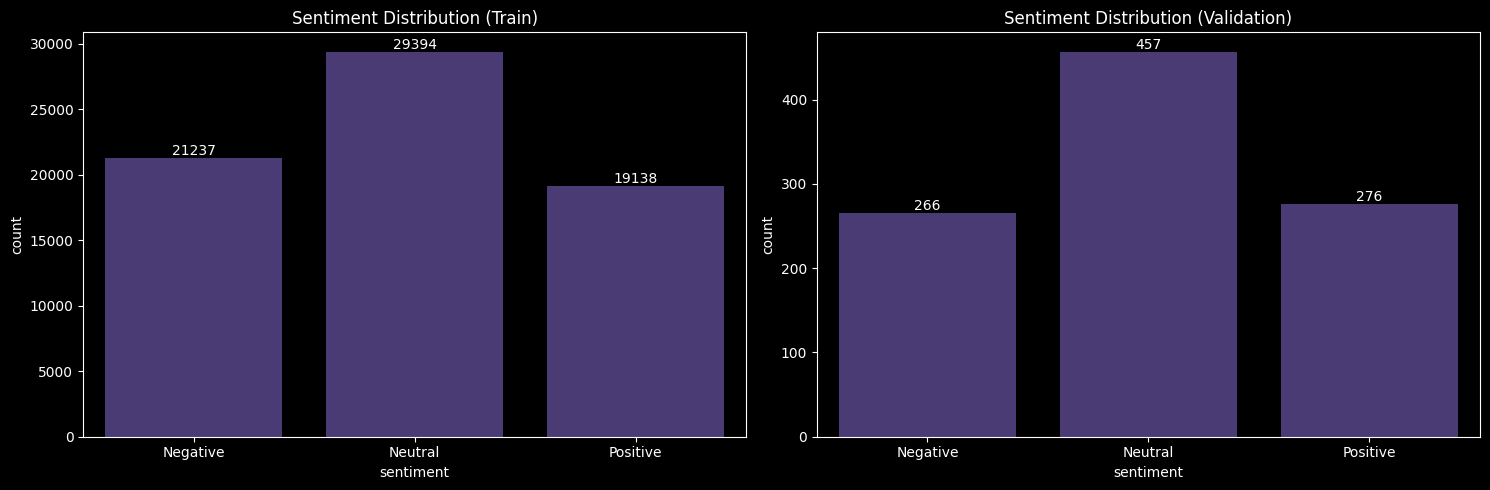

In [5]:
order = ['Negative', 'Neutral', 'Positive']
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.countplot(data=train, x='sentiment', order=order, ax=axes[0])
axes[0].set_title('Sentiment Distribution (Train)')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='bottom')

sns.countplot(data=val, x='sentiment', order=order, ax=axes[1])
axes[1].set_title('Sentiment Distribution (Validation)')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='bottom')

plt.tight_layout()
plt.show()


## 2. Text Preprocessing

In [6]:
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])
print("Active pipeline components:", nlp.pipe_names)

NEGATION_WHITELIST = {"n't", "not", "no", "never"}

def basic_clean(text):
    """Light regex pass before spaCy: lowercase, strip @mentions and URLs."""
    text = str(text).lower()
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'[^a-z\s\']', ' ', text)
    return text

def spacy_preprocess_series(series, batch_size=200):
    cleaned = series.apply(basic_clean).tolist()
    out = []
    for doc in nlp.pipe(cleaned, batch_size=batch_size):
        tokens = []
        for token in doc:
            if token.text in NEGATION_WHITELIST:
                tokens.append(token.text)
                continue
            if token.is_stop or token.is_punct or len(token.text) <= 1:
                continue
            tokens.append(token.lemma_)
        out.append(' '.join(tokens))
    return out


Active pipeline components: ['tok2vec', 'tagger', 'attribute_ruler', 'lemmatizer']


In [7]:
train['clean_text'] = spacy_preprocess_series(train['text'])

val['clean_text'] = spacy_preprocess_series(val['text'])

train = train[train['clean_text'].str.len() > 0].reset_index(drop=True)
val = val[val['clean_text'].str.len() > 0].reset_index(drop=True)
print(f"\nFinal shapes -> Train: {train.shape}   Validation: {val.shape}")

train[['text', 'clean_text']].sample(5, random_state=1)



Final shapes -> Train: (69268, 5)   Validation: (999, 5)


,text,clean_text
47850,What All the Little Things Made an Unbelievabl...,little thing unbelievable
4752,a Just got off the kiddos backpacks ordered ex...,get kiddo backpack order extra today click gre...
25901,"Oh, those fake bugs!",oh fake bug
22170,2014 I like it pic.twitter.com/cRuuFfv2ti,like pic twitter com cruuffv ti
64702,"Super misleading headline. Of course, as alway...",super misleading headline course people jump c...


In [8]:
le = LabelEncoder()
y_train = le.fit_transform(train['sentiment'])
y_val = le.transform(val['sentiment'])
print(dict(zip(le.classes_, le.transform(le.classes_))))


{'Negative': np.int64(0), 'Neutral': np.int64(1), 'Positive': np.int64(2)}


## 3. Classical Models — Naive Bayes & Random Forest


In [9]:
X_train_text = train['clean_text']
X_val_text = val['clean_text']


In [11]:
nb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=8000, ngram_range=(1, 2), min_df=3, sublinear_tf=True)),
    ('naive_bayes', MultinomialNB(fit_prior=False))
])
nb_pipeline.fit(X_train_text, y_train)

nb_preds = nb_pipeline.predict(X_val_text)
nb_acc = accuracy_score(y_val, nb_preds)
nb_f1 = f1_score(y_val, nb_preds, average='macro')
print(f"Naive Bayes  Accuracy={nb_acc:.4f}  Macro F1={nb_f1:.4f}\n")
print(classification_report(y_val, nb_preds, target_names=le.classes_))


Naive Bayes  Accuracy=0.7497  Macro F1=0.7505

              precision    recall  f1-score   support

    Negative       0.68      0.82      0.75       266
     Neutral       0.86      0.65      0.74       457
    Positive       0.70      0.84      0.76       276

    accuracy                           0.75       999
   macro avg       0.75      0.77      0.75       999
weighted avg       0.77      0.75      0.75       999



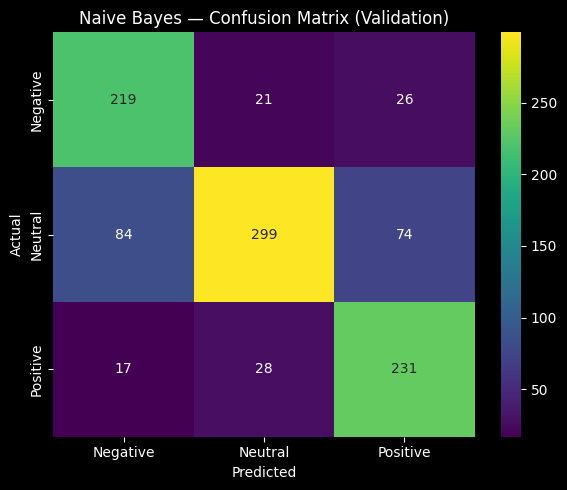

In [12]:
cm_nb = confusion_matrix(y_val, nb_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='viridis', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Naive Bayes — Confusion Matrix (Validation)')
plt.tight_layout()
plt.show()


In [13]:
rf_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=8000, ngram_range=(1, 2), min_df=3, sublinear_tf=True)),
    ('random_forest', RandomForestClassifier(
        n_estimators=300, max_depth=40, min_samples_leaf=2,
        class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE
    ))
])
rf_pipeline.fit(X_train_text, y_train)

rf_preds = rf_pipeline.predict(X_val_text)
rf_acc = accuracy_score(y_val, rf_preds)
rf_f1 = f1_score(y_val, rf_preds, average='macro')
print(f"Random Forest  Accuracy={rf_acc:.4f}  Macro F1={rf_f1:.4f}\n")
print(classification_report(y_val, rf_preds, target_names=le.classes_))


Random Forest  Accuracy=0.7928  Macro F1=0.7919

              precision    recall  f1-score   support

    Negative       0.74      0.86      0.80       266
     Neutral       0.85      0.75      0.80       457
    Positive       0.77      0.79      0.78       276

    accuracy                           0.79       999
   macro avg       0.79      0.80      0.79       999
weighted avg       0.80      0.79      0.79       999



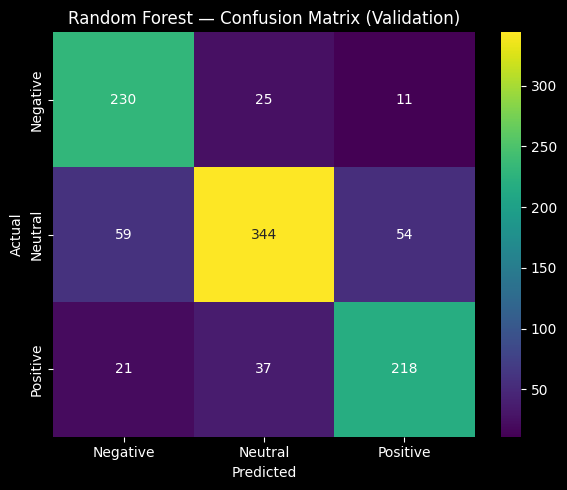

In [14]:
cm_rf = confusion_matrix(y_val, rf_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='viridis', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Random Forest — Confusion Matrix (Validation)')
plt.tight_layout()
plt.show()


## 4. Bidirectional LSTM


In [15]:
VOCAB_SIZE = 15000
MAX_LEN = 25

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(train['clean_text'])

X_train_seq = tokenizer.texts_to_sequences(train['clean_text'])
X_val_seq = tokenizer.texts_to_sequences(val['clean_text'])

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=MAX_LEN, padding='post', truncating='post')

num_classes = len(le.classes_)
y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes)
y_val_cat = tf.keras.utils.to_categorical(y_val, num_classes)

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))
print("Vocabulary size (actual):", min(VOCAB_SIZE, len(tokenizer.word_index) + 1))
print("Class weights:", {le.classes_[k]: round(v, 3) for k, v in class_weight_dict.items()})


Vocabulary size (actual): 15000
Class weights: {'Negative': np.float64(1.094), 'Neutral': np.float64(0.791), 'Positive': np.float64(1.216)}


In [16]:
X_tr, X_dev, y_tr, y_dev = train_test_split(
    X_train_pad, y_train_cat, test_size=0.1, random_state=RANDOM_STATE, stratify=y_train
)
print(f"Train: {X_tr.shape[0]}   Dev: {X_dev.shape[0]}")


Train: 62341   Dev: 6927


In [24]:
EMBED_DIM = 64

bilstm = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM),
    SpatialDropout1D(0.3),
    Bidirectional(LSTM(64, return_sequences=True, dropout=0.3)),
    Bidirectional(LSTM(32, dropout=0.3)),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])
bilstm.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
bilstm.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 25, 64)         │       960,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ (None, 25, 64)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 25, 128)        │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,069,571 (4.08 MB)

 Trainable params: 1,069,507 (4.08 MB)

 Non-trainable params: 64 (256.00 B)

In [25]:
early_stop = EarlyStopping(monitor='val_loss', mode='min', patience=3, restore_best_weights=True)

history = bilstm.fit(
    X_tr, y_tr, validation_data=(X_dev, y_dev),
    epochs=12, batch_size=320,
    class_weight=class_weight_dict,
    callbacks=[early_stop], verbose=2
)


Epoch 1/12
195/195 - 11s - 54ms/step - accuracy: 0.5958 - loss: 0.8437 - val_accuracy: 0.6056 - val_loss: 0.9153
Epoch 2/12
195/195 - 4s - 20ms/step - accuracy: 0.7860 - loss: 0.5240 - val_accuracy: 0.8197 - val_loss: 0.5219
Epoch 3/12
195/195 - 3s - 17ms/step - accuracy: 0.8427 - loss: 0.3977 - val_accuracy: 0.8435 - val_loss: 0.3871
Epoch 4/12
195/195 - 3s - 16ms/step - accuracy: 0.8682 - loss: 0.3380 - val_accuracy: 0.8393 - val_loss: 0.3990
Epoch 5/12
195/195 - 6s - 31ms/step - accuracy: 0.8838 - loss: 0.2966 - val_accuracy: 0.8463 - val_loss: 0.4020
Epoch 6/12
195/195 - 5s - 24ms/step - accuracy: 0.8947 - loss: 0.2696 - val_accuracy: 0.8565 - val_loss: 0.3788
Epoch 7/12
195/195 - 7s - 37ms/step - accuracy: 0.9034 - loss: 0.2485 - val_accuracy: 0.8653 - val_loss: 0.3769
Epoch 8/12
195/195 - 5s - 25ms/step - accuracy: 0.9067 - loss: 0.2358 - val_accuracy: 0.8672 - val_loss: 0.3644
Epoch 9/12
195/195 - 4s - 20ms/step - accuracy: 0.9131 - loss: 0.2216 - val_accuracy: 0.8659 - val_loss

In [26]:
bilstm_preds = np.argmax(bilstm.predict(X_val_pad, verbose=0), axis=1)
bilstm_acc = accuracy_score(y_val, bilstm_preds)
bilstm_f1 = f1_score(y_val, bilstm_preds, average='macro')
print(f"BiLSTM  Accuracy={bilstm_acc:.4f}  Macro F1={bilstm_f1:.4f}\n")
print(classification_report(y_val, bilstm_preds, target_names=le.classes_))


BiLSTM  Accuracy=0.9379  Macro F1=0.9359

              precision    recall  f1-score   support

    Negative       0.95      0.94      0.94       266
     Neutral       0.97      0.93      0.95       457
    Positive       0.88      0.95      0.91       276

    accuracy                           0.94       999
   macro avg       0.93      0.94      0.94       999
weighted avg       0.94      0.94      0.94       999



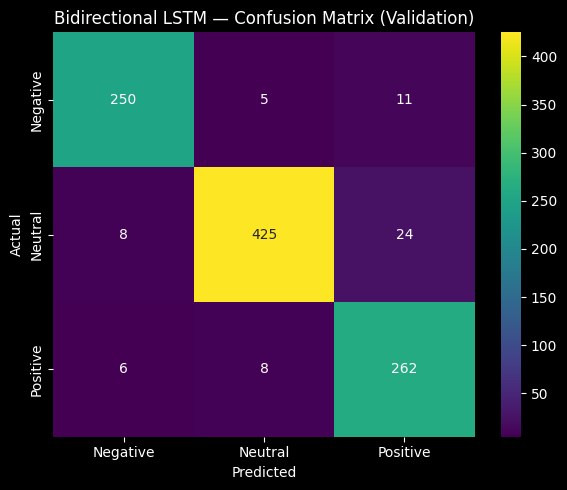

In [27]:
cm_bilstm = confusion_matrix(y_val, bilstm_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_bilstm, annot=True, fmt='d', cmap='viridis', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Bidirectional LSTM — Confusion Matrix (Validation)')
plt.tight_layout()
plt.show()


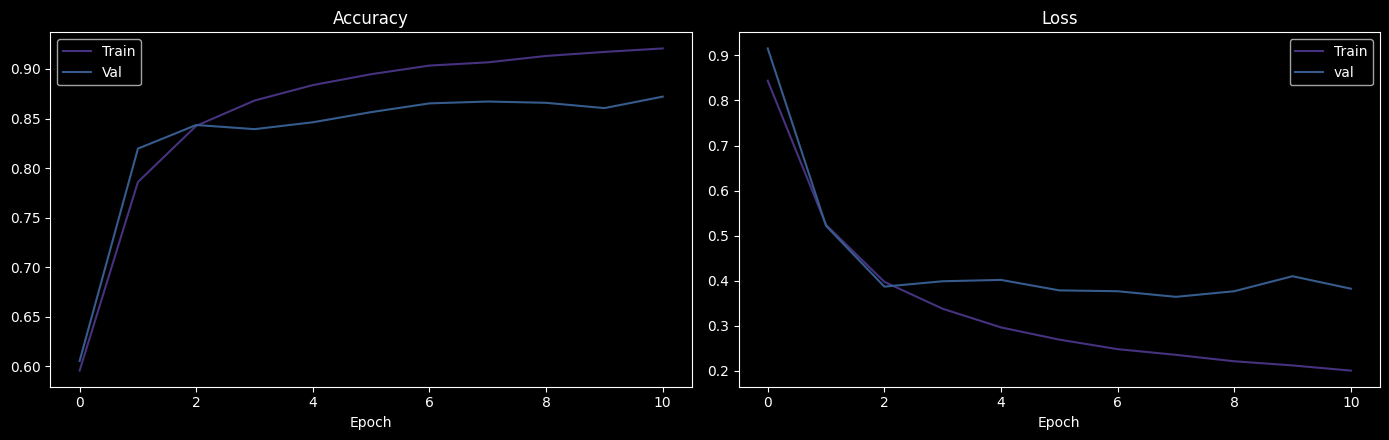

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='val')
axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch'); axes[1].legend()

plt.tight_layout()
plt.show()


## 5. Model Comparison

In [29]:
results_df = pd.DataFrame({
    'Naive Bayes': {'Accuracy': nb_acc, 'Macro F1': nb_f1},
    'Random Forest': {'Accuracy': rf_acc, 'Macro F1': rf_f1},
    'Bidirectional LSTM': {'Accuracy': bilstm_acc, 'Macro F1': bilstm_f1},
}).T.sort_values('Macro F1', ascending=False).round(4)

results_df


,Accuracy,Macro F1
Bidirectional LSTM,0.9379,0.9359
Random Forest,0.7928,0.7919
Naive Bayes,0.7497,0.7505


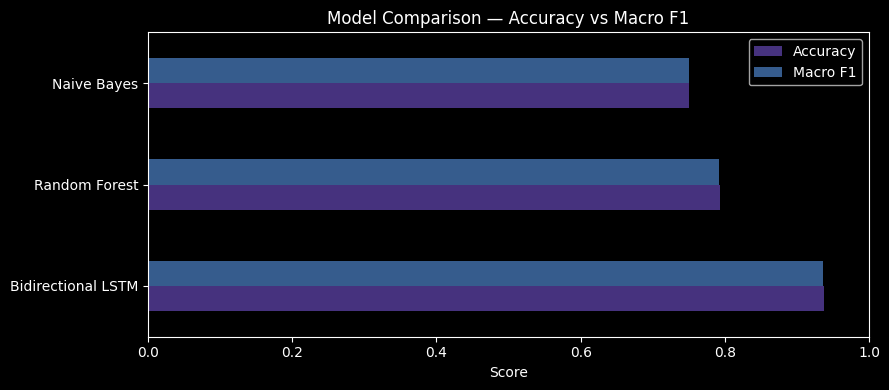

In [31]:
results_df.plot(kind='barh', figsize=(9, 4))
plt.title('Model Comparison — Accuracy vs Macro F1')
plt.xlabel('Score'); plt.xlim(0, 1)
plt.tight_layout()
plt.show()


## 6. Conclusion

| Model | Accuracy | Macro F1 |
|---|---|---|
| **Bidirectional LSTM** | **0.9379** | **0.9359** |
| Random Forest | 0.7928 | 0.7919 |
| Naive Bayes | 0.7497 | 0.7505 |

The **Bidirectional LSTM decisively outperforms both classical models**, consistent with a companion sentiment project's finding that deep sequence models pull ahead when there's enough training data (here, ~62K training sequences) and the task involves context-dependent slang (e.g. "murder"/"kill" as gaming hype-speech, not literal violence) — signal a bag-of-words TF-IDF representation mostly can't capture.
